In [1]:
import anndata as ad
import numpy as np
import pandas as pd
import SDP_miRNA.dataset
import SDP_miRNA.optimization
import SDP_miRNA.optimization_MOSEK
import SDP_miRNA.correlation
import matplotlib.pyplot as plt

In [291]:
rng = np.random.default_rng(423)

# mRNA - mRNA Correlations

# Loading

In [292]:
# load pcRNA
adata_pcRNA = ad.read_h5ad("TotalX_HEK293T_pcRNA.h5ad")

# load miRNA
adata_miRNA = ad.read_h5ad("TotalX_HEK293T_miRNA.h5ad")

# load capture
beta = np.loadtxt("TotalX_HEK293T_capture.txt")

In [293]:
# load results
ind_MF_df = pd.read_csv("Results/New/independent_MF.csv", index_col=0)
int_MF_df = pd.read_csv("Results/New/interacting_MF.csv", index_col=0)
corr_df = pd.read_csv("Results/New/correlation.csv", index_col=0)

In [294]:
# choose miRNA
miRNA = "MIR4709" # "MIR3655"

# select results
ind = ind_MF_df[f'{miRNA}_status']
mid = int_MF_df[f'{miRNA}_HAR_mid']

# Running

## Selection

In [295]:
# size
M = 25

# get names of negatively correlated interacting pcRNA
names_neg = mid[mid < -0.25].index.tolist()
names_neg = rng.choice(names_neg, size=M, replace=False)

# get names of positively correlated interacting pcRNA
names_pos = mid[mid > 0.25].index.tolist()
names_pos = rng.choice(names_pos, size=M, replace=False)

# get names of independent pcRNA
mask_ind = (ind == "OPTIMAL")
names_ind = mask_ind.index[mask_ind.values.squeeze()].tolist()
names_ind = rng.choice(names_ind, size=M, replace=False)

# subset adata
adata_neg = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_neg)]
adata_pos = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_pos)]
adata_ind = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_ind)]

## Correlations between each group

In [7]:
# compute correlations between all pairs of M genes: no repeats
Is, Js = np.triu_indices(M, k=1)
gene_queries = [
    [[int(i)], [int(j)]] for i, j in zip(Is, Js)
]

# construct datasets
data_neg = SDP_miRNA.dataset.Dataset()
data_pos = SDP_miRNA.dataset.Dataset()
data_ind = SDP_miRNA.dataset.Dataset()

data_neg.construct_dataset_adata(adata_neg, adata_neg, beta, gene_queries)
data_pos.construct_dataset_adata(adata_pos, adata_pos, beta, gene_queries)
data_ind.construct_dataset_adata(adata_ind, adata_ind, beta, gene_queries)

# bootstrap
data_neg.bootstrap(d=3)
data_pos.bootstrap(d=3)
data_ind.bootstrap(d=3)

100%|██████████| 3/3 [00:03<00:00,  1.25s/it]


In [8]:
# model free independence test
MF_ind_neg = SDP_miRNA.optimization.ModelFreeOptimization(data_neg, d=3)
MF_ind_pos = SDP_miRNA.optimization.ModelFreeOptimization(data_pos, d=3)
MF_ind_ind = SDP_miRNA.optimization.ModelFreeOptimization(data_ind, d=3)
MF_ind_neg.analyse_dataset()
MF_ind_pos.analyse_dataset()
MF_ind_ind.analyse_dataset()

100%|██████████| 300/300 [00:10<00:00, 29.86it/s]


In [9]:
# model free interacting H&R: should really subset queries to just interacting pairs, but small enough
MF_int_neg = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data_neg, d=3)
MF_int_pos = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data_pos, d=3)
MF_int_ind = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data_ind, d=3)
MF_int_neg.analyse_dataset()
MF_int_pos.analyse_dataset()
MF_int_ind.analyse_dataset()

 81%|████████  | 242/300 [02:50<00:38,  1.50it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


100%|██████████| 300/300 [03:25<00:00,  1.46it/s]


In [10]:
# H&R correlations
HAR_points_neg, HAR_intervals_neg = MF_int_neg.compute_dataset_correlation()
HAR_points_pos, HAR_intervals_pos = MF_int_pos.compute_dataset_correlation()
HAR_points_ind, HAR_intervals_ind = MF_int_ind.compute_dataset_correlation()

 80%|████████  | 241/300 [00:05<00:01, 46.98it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 395, in compute_dataset_correlation
    correlation_list = [
TypeError: 'NoneType' object is not iterable
 84%|████████▍ | 252/300 [00:05<00:00, 48.71it/s]

Computation failed: 'NoneType' object is not iterable


100%|██████████| 300/300 [00:06<00:00, 47.49it/s]


In [11]:
# H&R midpoints
HAR_mid_neg = (HAR_intervals_neg[:, 0] + HAR_intervals_neg[:, 1]) / 2
HAR_mid_pos = (HAR_intervals_pos[:, 0] + HAR_intervals_pos[:, 1]) / 2
HAR_mid_ind = (HAR_intervals_ind[:, 0] + HAR_intervals_ind[:, 1]) / 2

In [12]:
# correlation
OB_neg, AL_neg = SDP_miRNA.correlation.compute_correlations(data_neg)
OB_pos, AL_pos = SDP_miRNA.correlation.compute_correlations(data_pos)
OB_ind, AL_ind = SDP_miRNA.correlation.compute_correlations(data_ind)

100%|██████████| 3/3 [00:01<00:00,  1.57it/s]


## Correlations between groups

In [13]:
# compute correlations between all pairs of M genes
gene_queries = [
    [[int(i)], [int(j)]] for i in range(M) for j in range(M)
]

# construct datasets
data_neg_pos = SDP_miRNA.dataset.Dataset()
data_neg_pos.construct_dataset_adata(adata_neg, adata_pos, beta, gene_queries)

# bootstrap
data_neg_pos.bootstrap(d=3)

100%|██████████| 7/7 [00:10<00:00,  1.45s/it]


In [14]:
# model free independence test
MF_ind_neg_pos = SDP_miRNA.optimization.ModelFreeOptimization(data_neg_pos, d=3)
MF_ind_neg_pos.analyse_dataset()

  0%|          | 0/625 [00:00<?, ?it/s]

100%|██████████| 625/625 [00:20<00:00, 30.20it/s]


In [15]:
# model free interacting H&R: should really subset queries to just interacting pairs, but small enough
MF_int_neg_pos = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data_neg_pos, d=3)
MF_int_neg_pos.analyse_dataset()

 89%|████████▉ | 557/625 [06:18<00:45,  1.49it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range
Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range
Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range
Optimization failed: list index out of range
Optimization failed: list index out of range


 91%|█████████ | 567/625 [06:22<00:35,  1.65it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


 91%|█████████ | 569/625 [06:23<00:27,  2.04it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


100%|██████████| 625/625 [07:00<00:00,  1.49it/s]


In [16]:
# H&R correlations
HAR_points_neg_pos, HAR_intervals_neg_pos = MF_int_neg_pos.compute_dataset_correlation()

 89%|████████▉ | 555/625 [00:10<00:01, 51.67it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 395, in compute_dataset_correlation
    correlation_list = [
TypeError: 'NoneType' object is not iterable
Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 395, in compute_dataset_correlation
    correlation_list = [
TypeError: 'NoneType' object is not iterable
Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 395, in compute_dataset_correlation
    correlation_list = [
TypeError: 'NoneType' object is not iterable
 90%|█████████ | 564/625 [00:11<00:01, 59.04it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", l

Computation failed: 'NoneType' object is not iterable
Computation failed: 'NoneType' object is not iterable
Computation failed: 'NoneType' object is not iterable
Computation failed: 'NoneType' object is not iterable
Computation failed: 'NoneType' object is not iterable


100%|██████████| 625/625 [00:12<00:00, 51.13it/s]


In [17]:
# H&R midpoints
HAR_mid_neg_pos = (HAR_intervals_neg_pos[:, 0] + HAR_intervals_neg_pos[:, 1]) / 2

In [18]:
# correlation
OB_neg_pos, AL_neg_pos = SDP_miRNA.correlation.compute_correlations(data_neg_pos)

100%|██████████| 7/7 [00:03<00:00,  1.81it/s]


# Results

- plot new miRNA results above old (keep old plot)

## Violin

### Exclude correlations of independent pairs

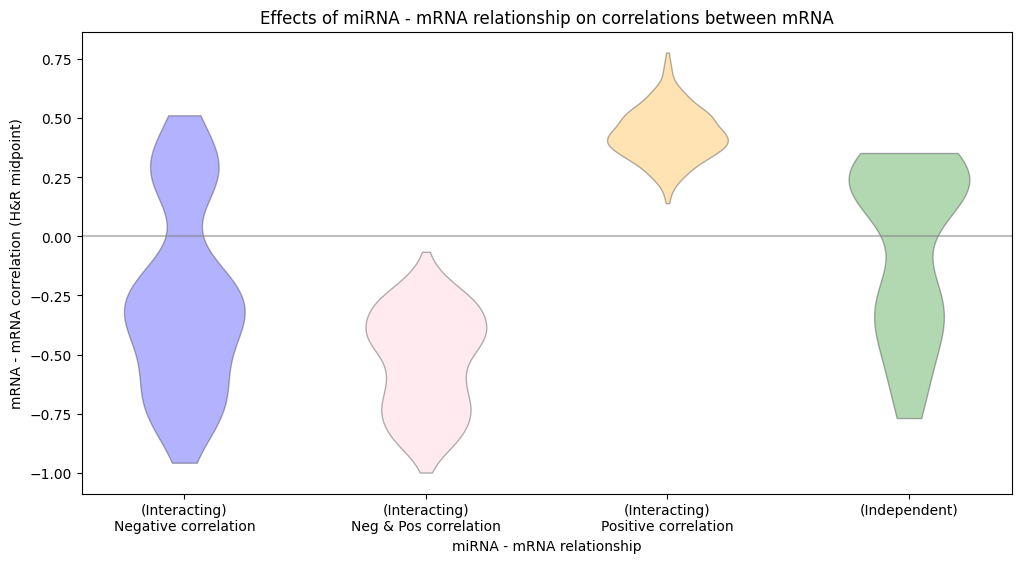

In [19]:
# remove correlations of independent pairs
ind_list = [MF_ind_neg, MF_ind_neg_pos, MF_ind_pos, MF_ind_ind]
mid_list = [HAR_mid_neg, HAR_mid_neg_pos, HAR_mid_pos, HAR_mid_ind]
plot_data_list = []
for indx, midx in zip(ind_list, mid_list):
    mask = np.array([True if sol['status'] == "INFEASIBLE" else False for sol in indx.result_dict.values()])
    midx = midx[mask]
    # also drop any nan
    midx = midx[~np.isnan(midx)]
    plot_data_list.append(midx)

# plot
fig, axs = plt.subplots(figsize=(12, 6))
plot_colors = ["blue", "pink", "orange", "green"]
plot_labels = ["A", "B", "C", "D"]
for i, plot_data in enumerate(plot_data_list):
    vp = axs.violinplot(
        dataset=plot_data,
        positions=[i],
        showextrema=False,
        side="both"
    )
    plt.setp(vp['bodies'], facecolor=plot_colors[i], edgecolor='black')
axs.axhline(0, color="grey", alpha=0.5)
axs.set_xticks([0, 1, 2, 3])
axs.set_xticklabels(["(Interacting)\nNegative correlation", "(Interacting)\nNeg & Pos correlation", "(Interacting)\nPositive correlation", "(Independent)"])
axs.set_xlabel("miRNA - mRNA relationship")
axs.set_ylabel("mRNA - mRNA correlation (H&R midpoint)")
axs.set_title("Effects of miRNA - mRNA relationship on correlations between mRNA")
plt.show()

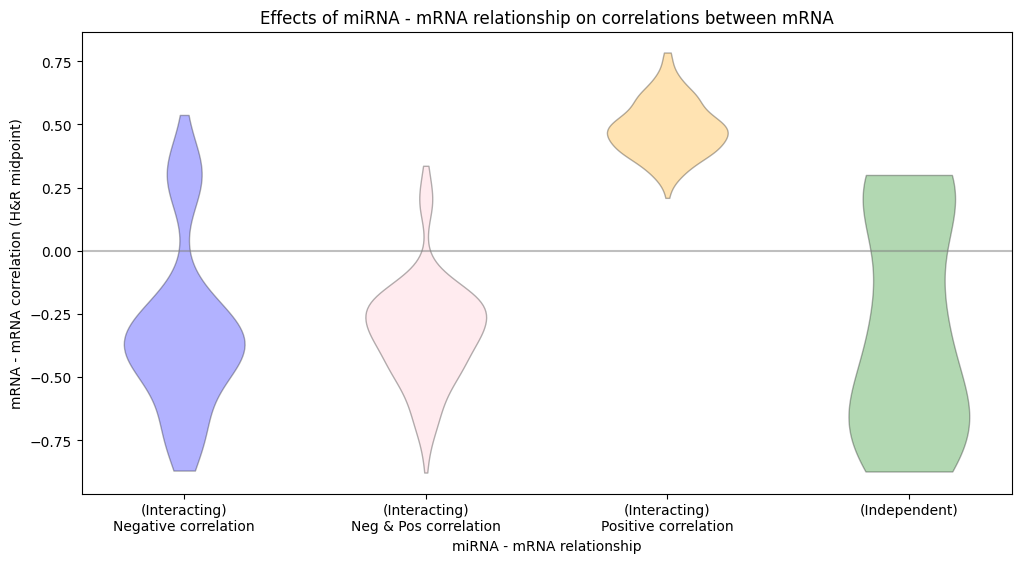

In [ ]:
# MIR3655

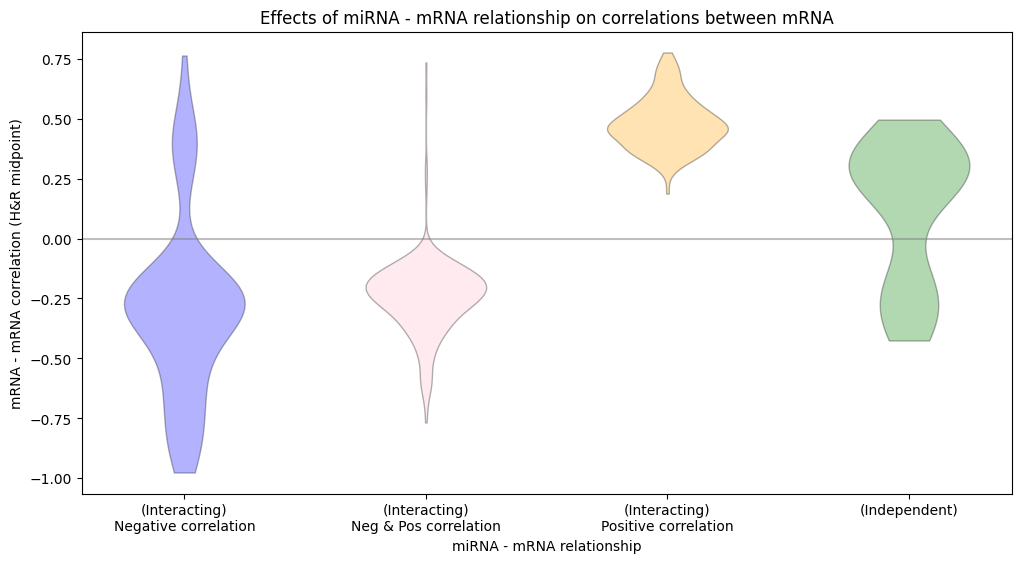

In [ ]:
# MIR3655

### Include correlations of independent pairs

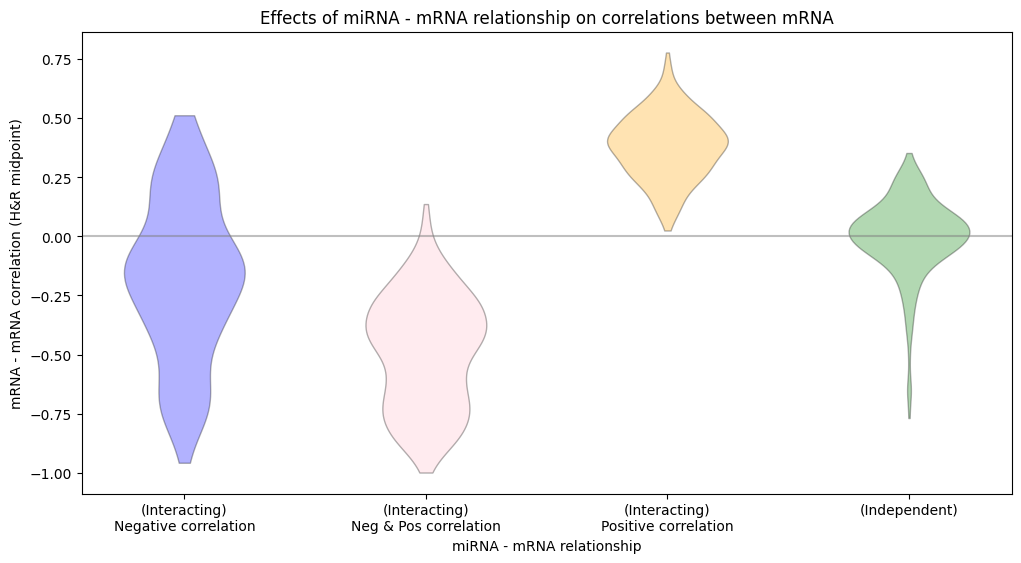

In [21]:
fig, axs = plt.subplots(figsize=(12, 6))
plot_data_list = [HAR_mid_neg[~np.isnan(HAR_mid_neg)], HAR_mid_neg_pos[~np.isnan(HAR_mid_neg_pos)], HAR_mid_pos, HAR_mid_ind]
plot_colors = ["blue", "pink", "orange", "green"]
plot_labels = ["A", "B", "C", "D"]
for i, plot_data in enumerate(plot_data_list):
    vp = axs.violinplot(
        dataset=plot_data,
        positions=[i],
        showextrema=False,
        side="both"
    )
    plt.setp(vp['bodies'], facecolor=plot_colors[i], edgecolor='black')
axs.axhline(0, color="grey", alpha=0.5)
axs.set_xticks([0, 1, 2, 3])
axs.set_xticklabels(["(Interacting)\nNegative correlation", "(Interacting)\nNeg & Pos correlation", "(Interacting)\nPositive correlation", "(Independent)"])
axs.set_xlabel("miRNA - mRNA relationship")
axs.set_ylabel("mRNA - mRNA correlation (H&R midpoint)")
axs.set_title("Effects of miRNA - mRNA relationship on correlations between mRNA")
plt.show()

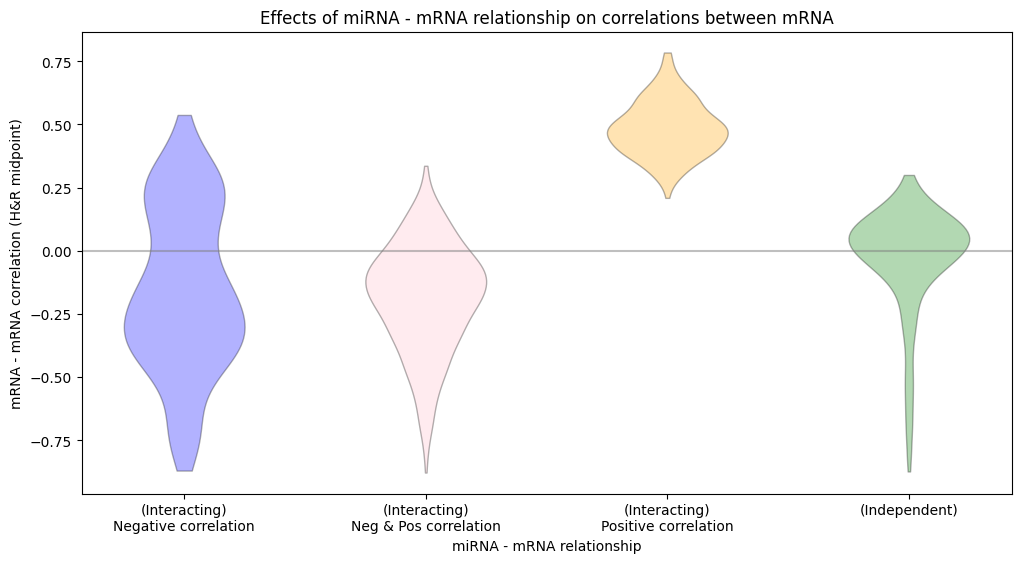

In [ ]:
# MIR3655

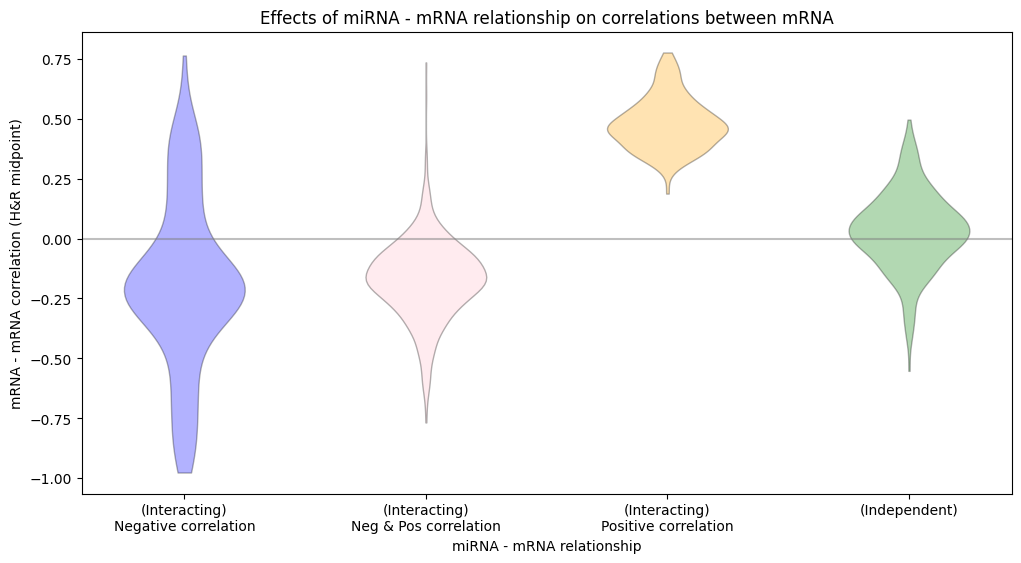

In [ ]:
# MIR3655

## Heatmap

In [22]:
from matplotlib.colors import LinearSegmentedColormap

In [23]:
corr_matrix_neg = np.zeros((M, M))
corr_matrix_neg_pos = np.zeros((M, M))
corr_matrix_pos = np.zeros((M, M))
corr_matrix_ind = np.zeros((M, M))
for i, query in enumerate(data_neg.gene_queries):
    if MF_ind_neg.result_dict[i]['status'] == "INFEASIBLE":
        corr_matrix_neg[query[0][0], query[1][0]] = HAR_mid_neg[i]
for i, query in enumerate(data_neg_pos.gene_queries):
    if MF_ind_neg_pos.result_dict[i]['status'] == "INFEASIBLE":
        corr_matrix_neg_pos[query[0][0], query[1][0]] = HAR_mid_neg_pos[i]
for i, query in enumerate(data_pos.gene_queries):
    if MF_ind_pos.result_dict[i]['status'] == "INFEASIBLE":
        corr_matrix_pos[query[0][0], query[1][0]] = HAR_mid_pos[i]
for i, query in enumerate(data_ind.gene_queries):
    if MF_ind_ind.result_dict[i]['status'] == "INFEASIBLE":
        corr_matrix_ind[query[0][0], query[1][0]] = HAR_mid_ind[i]

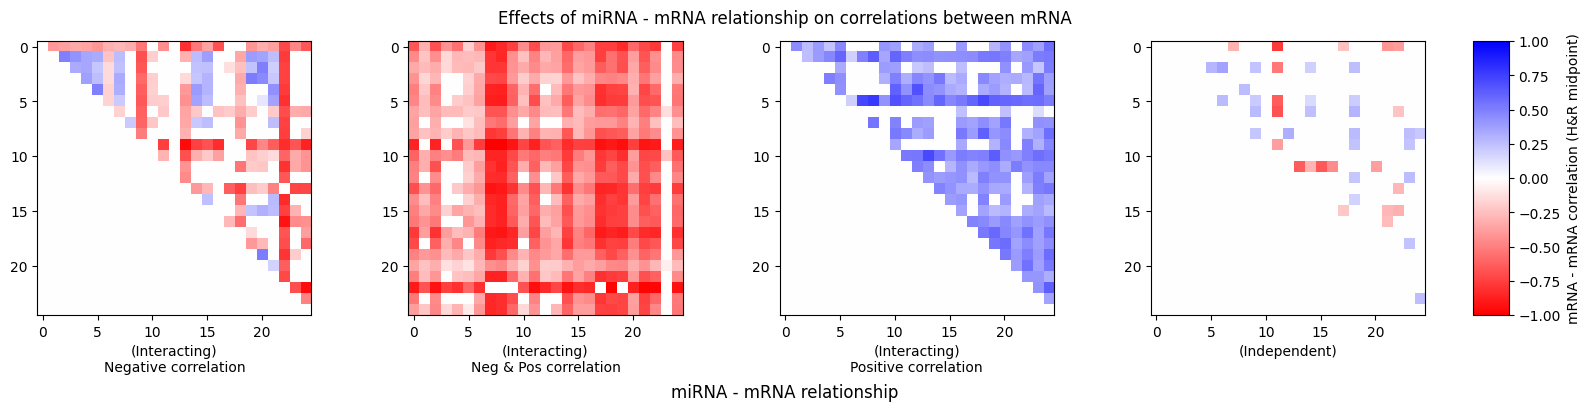

In [24]:
cmap = LinearSegmentedColormap.from_list('a', ['red', 'white', 'blue'])
fig, axs = plt.subplots(1, 5, figsize=(16, 4), gridspec_kw={'width_ratios': [1, 1, 1, 1, 0.1]}, constrained_layout=True)
im = axs[0].imshow(corr_matrix_neg, cmap=cmap, vmin=-1, vmax=1)
im = axs[1].imshow(corr_matrix_neg_pos, cmap=cmap, vmin=-1, vmax=1)
im = axs[2].imshow(corr_matrix_pos, cmap=cmap, vmin=-1, vmax=1)
im = axs[3].imshow(corr_matrix_ind, cmap=cmap, vmin=-1, vmax=1)
axs[0].set_xlabel("(Interacting)\nNegative correlation")
axs[1].set_xlabel("(Interacting)\nNeg & Pos correlation")
axs[2].set_xlabel("(Interacting)\nPositive correlation")
axs[3].set_xlabel("(Independent)")
fig.supxlabel("miRNA - mRNA relationship")
fig.suptitle("Effects of miRNA - mRNA relationship on correlations between mRNA")
plt.colorbar(im, cax=axs[4], label="mRNA - mRNA correlation (H&R midpoint)")
plt.show()

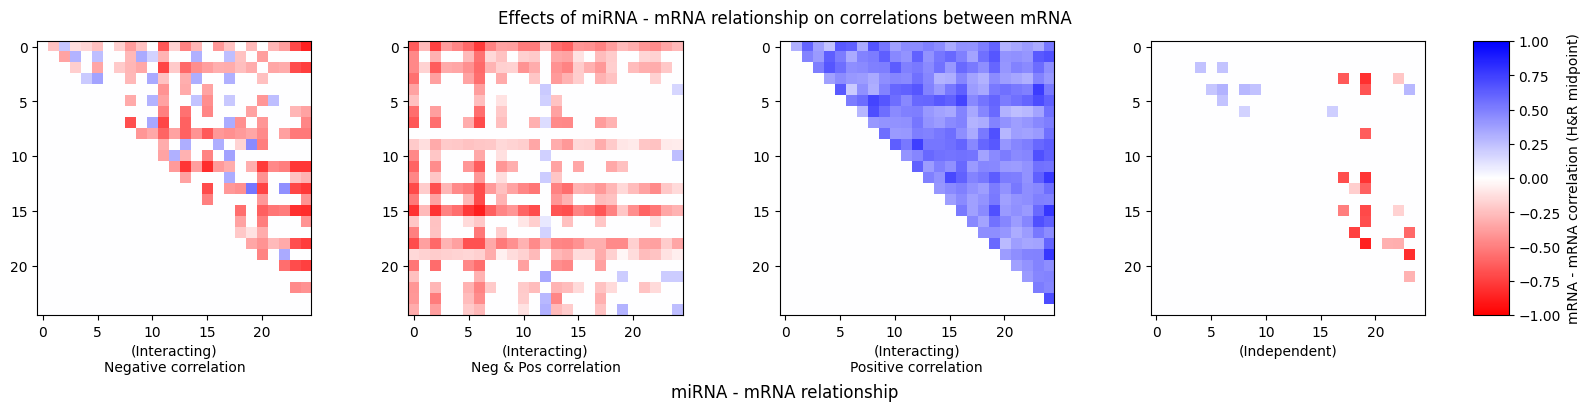

In [ ]:
# MIR3655

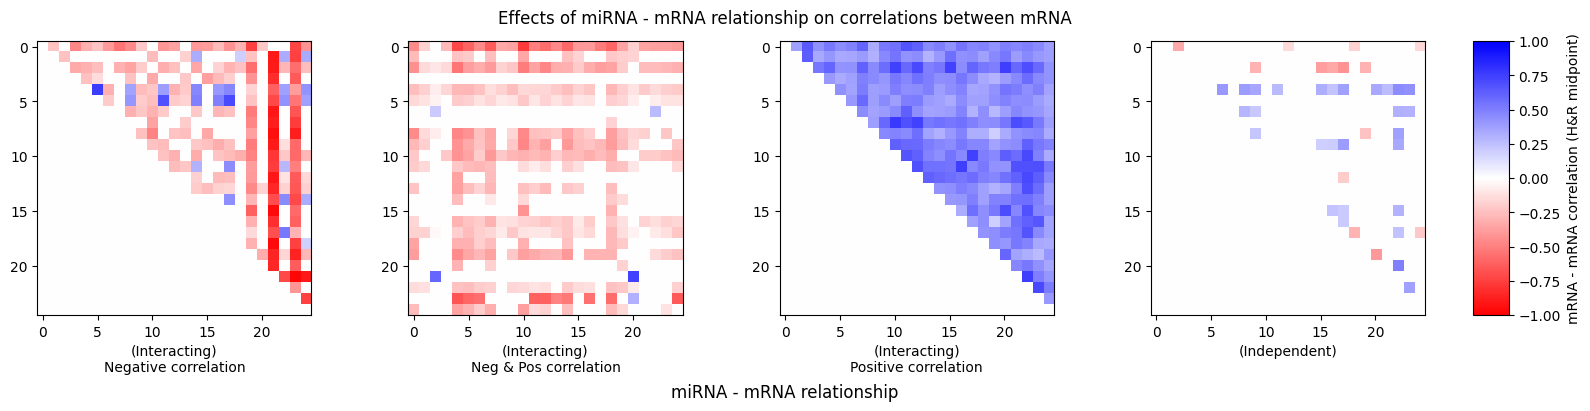

In [ ]:
# MIR3655

## Scatter

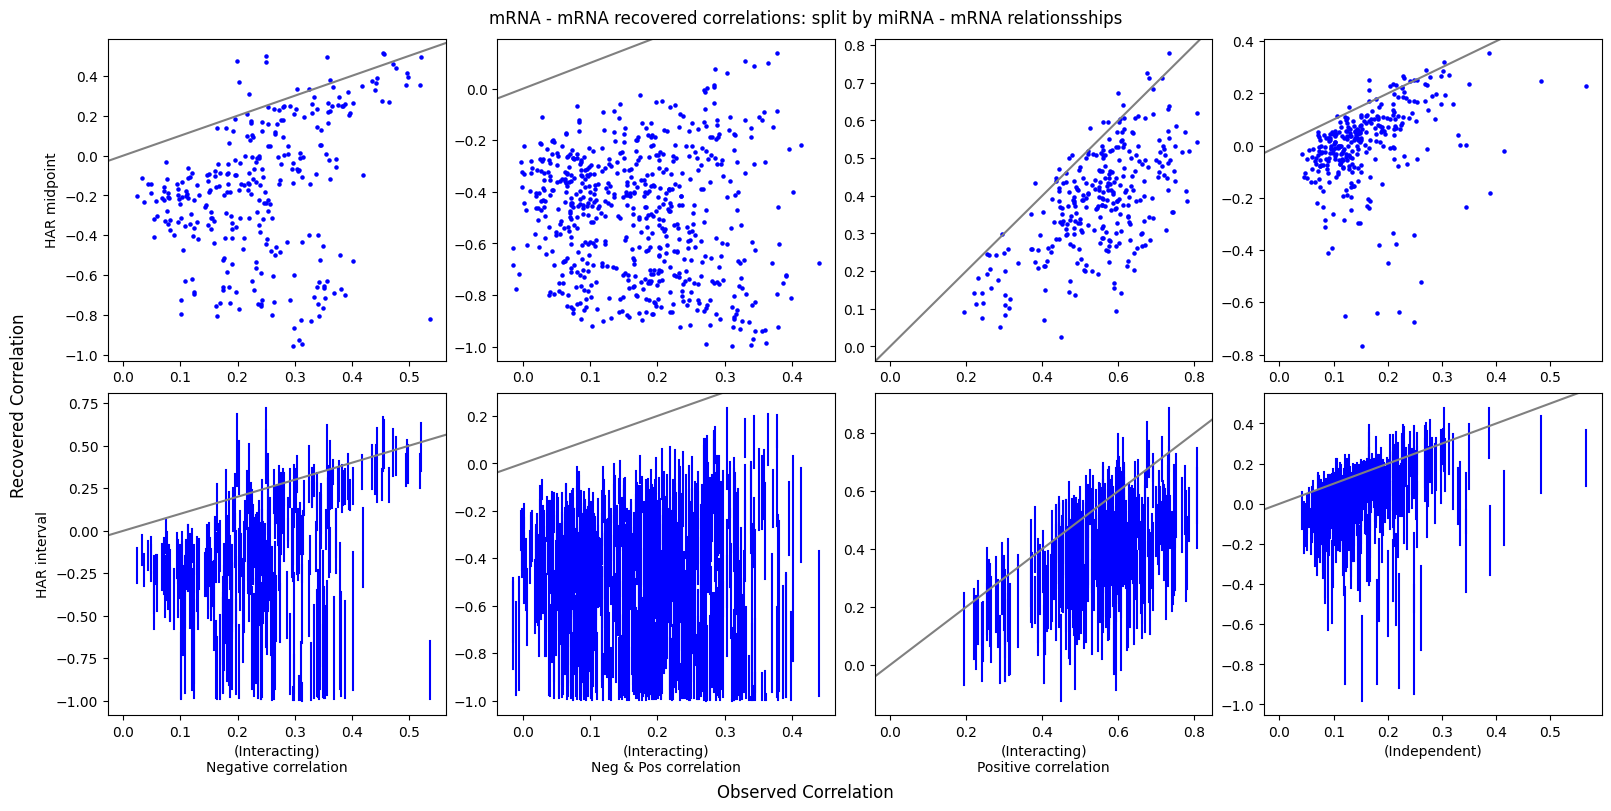

In [25]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)
axs[0, 0].scatter(OB_neg[:, 0], HAR_mid_neg, s=5, color="blue")
axs[0, 1].scatter(OB_neg_pos[:, 0], HAR_mid_neg_pos, s=5, color="blue")
axs[0, 2].scatter(OB_pos[:, 0], HAR_mid_pos, s=5, color="blue")
axs[0, 3].scatter(OB_ind[:, 0], HAR_mid_ind, s=5, color="blue")
axs[1, 0].plot([OB_neg[:, 0], OB_neg[:, 0]], [HAR_intervals_neg[:, 0], HAR_intervals_neg[:, 1]], color="blue");
axs[1, 1].plot([OB_neg_pos[:, 0], OB_neg_pos[:, 0]], [HAR_intervals_neg_pos[:, 0], HAR_intervals_neg_pos[:, 1]], color="blue");
axs[1, 2].plot([OB_pos[:, 0], OB_pos[:, 0]], [HAR_intervals_pos[:, 0], HAR_intervals_pos[:, 1]], color="blue");
axs[1, 3].plot([OB_ind[:, 0], OB_ind[:, 0]], [HAR_intervals_ind[:, 0], HAR_intervals_ind[:, 1]], color="blue");
for i in range(2):
    for j in range(4):
        axs[i, j].axline([0]*2, [0.1]*2, color="grey")
axs[0, 0].set_ylabel("HAR midpoint")
axs[1, 0].set_ylabel("HAR interval")
fig.supylabel("Recovered Correlation")
axs[1, 0].set_xlabel("(Interacting)\nNegative correlation")
axs[1, 1].set_xlabel("(Interacting)\nNeg & Pos correlation")
axs[1, 2].set_xlabel("(Interacting)\nPositive correlation")
axs[1, 3].set_xlabel("(Independent)")
fig.supxlabel("Observed Correlation")
fig.suptitle("mRNA - mRNA recovered correlations: split by miRNA - mRNA relationsships")
plt.show()

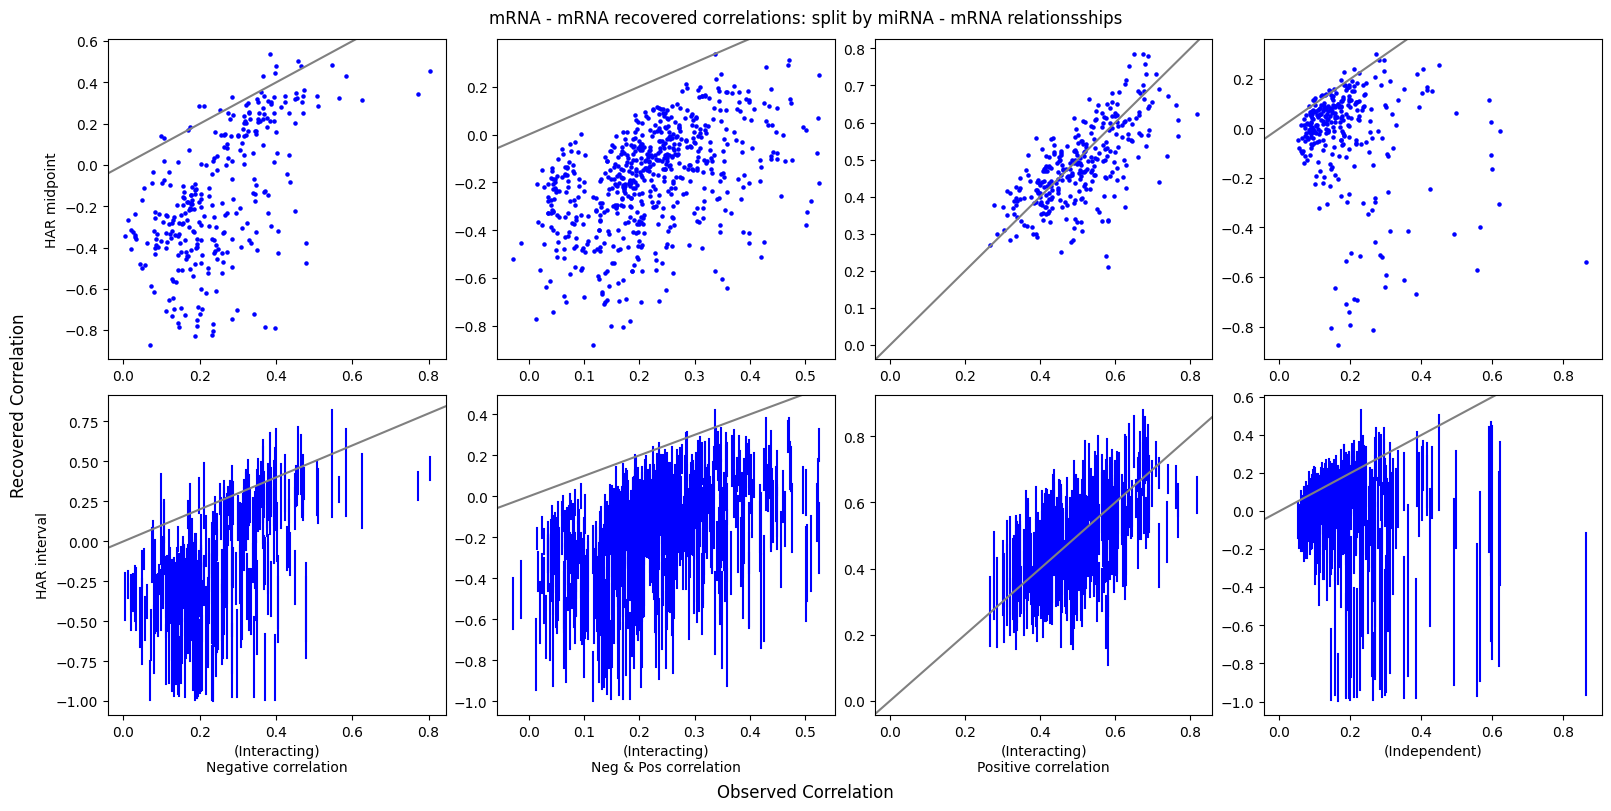

In [ ]:
# MIR3655

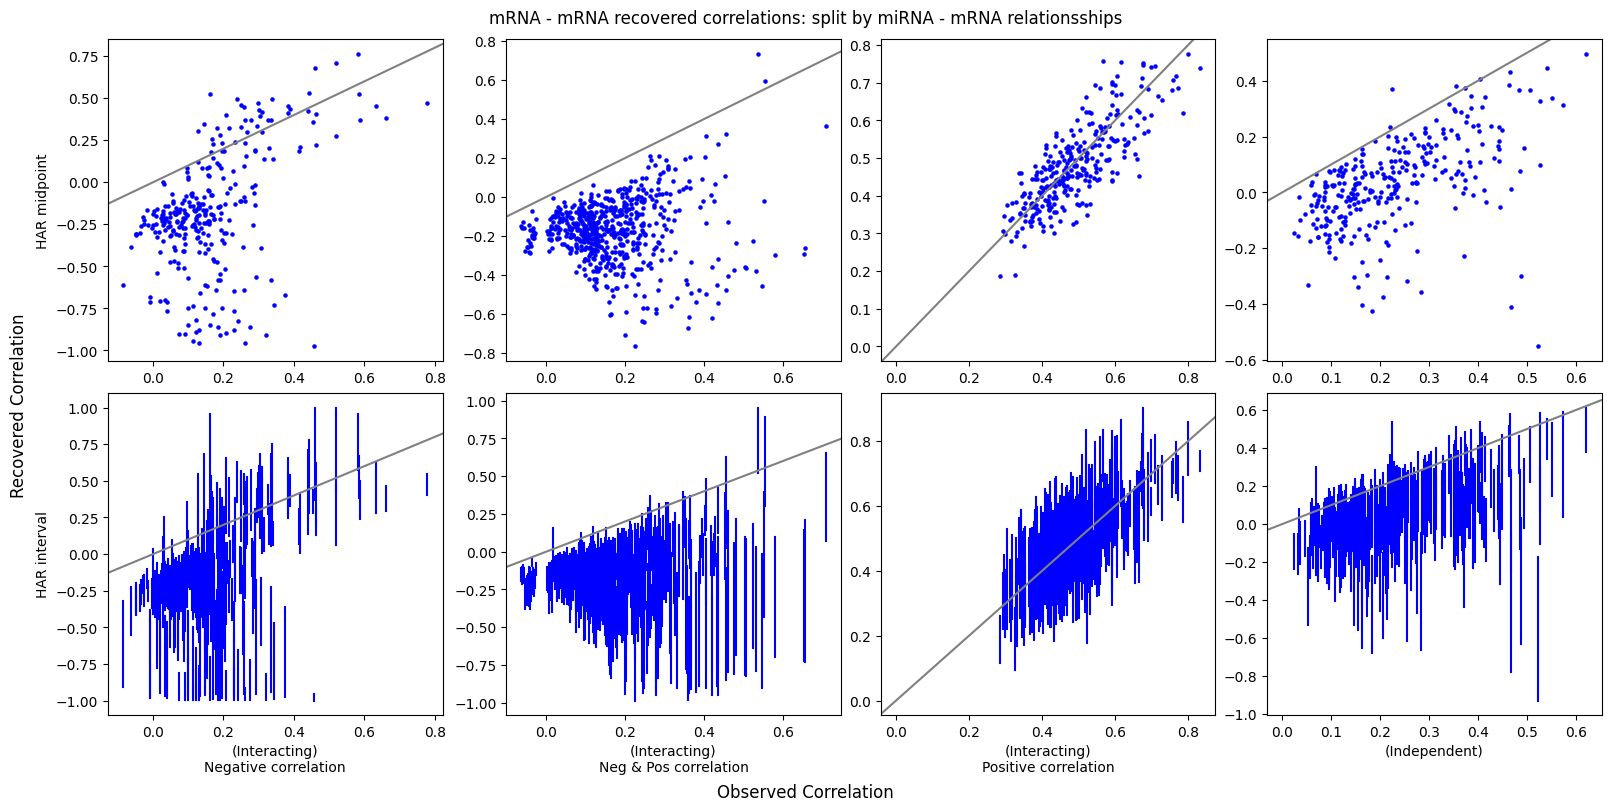

In [ ]:
# MIR3655

# Triplet Correlations

Have separately obtained correlations between miRNA and target mRNA, and between the target mRNA

Combine to a single triplet of miRNA and mRNA pairs

In [26]:
# compute correlations between all pairs of M genes + miRNA: no repeats
Is, Js = np.triu_indices(M, k=1)
gene_queries = [
    [[0], [int(i), int(j)]] for i, j in zip(Is, Js)
]


# construct datasets
data_neg_triplet = SDP_miRNA.dataset.Dataset()
data_neg_triplet.construct_dataset_adata(
    adata_miRNA[:, adata_miRNA.var['GeneName'] == miRNA],
    adata_neg,
    beta,
    gene_queries
)

# bootstrap
data_neg_triplet.bootstrap(d=3)

100%|██████████| 3/3 [00:08<00:00,  2.91s/it]


In [28]:
# model free interacting H&R: should really subset queries to just interacting pairs, but small enough
MF_int_neg_triplet = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data_neg_triplet, d=3)
MF_int_neg_triplet.analyse_dataset()

 81%|████████  | 242/300 [04:56<01:11,  1.24s/it]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


100%|██████████| 300/300 [06:06<00:00,  1.22s/it]


In [29]:
# H&R correlations
_, HAR_intervals_neg_triplet_01 = MF_int_neg_triplet.compute_dataset_correlation(Sx=0, Sy=1)
_, HAR_intervals_neg_triplet_02 = MF_int_neg_triplet.compute_dataset_correlation(Sx=0, Sy=2)
_, HAR_intervals_neg_triplet_12 = MF_int_neg_triplet.compute_dataset_correlation(Sx=1, Sy=2)

 80%|████████  | 241/300 [00:06<00:01, 34.24it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 395, in compute_dataset_correlation
    correlation_list = [
TypeError: 'NoneType' object is not iterable
 82%|████████▏ | 247/300 [00:07<00:01, 37.87it/s]

Computation failed: 'NoneType' object is not iterable


 80%|███████▉  | 239/300 [00:07<00:01, 34.65it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 395, in compute_dataset_correlation
    correlation_list = [
TypeError: 'NoneType' object is not iterable
 82%|████████▏ | 247/300 [00:07<00:01, 35.86it/s]

Computation failed: 'NoneType' object is not iterable


 80%|████████  | 240/300 [00:07<00:01, 32.06it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 395, in compute_dataset_correlation
    correlation_list = [
TypeError: 'NoneType' object is not iterable
 83%|████████▎ | 249/300 [00:07<00:01, 34.13it/s]

Computation failed: 'NoneType' object is not iterable


100%|██████████| 300/300 [00:09<00:00, 32.93it/s]


In [30]:
# H&R midpoints
HAR_mid_neg_triplet_01 = (HAR_intervals_neg_triplet_01[:, 0] + HAR_intervals_neg_triplet_01[:, 1]) / 2
HAR_mid_neg_triplet_02 = (HAR_intervals_neg_triplet_02[:, 0] + HAR_intervals_neg_triplet_02[:, 1]) / 2
HAR_mid_neg_triplet_12 = (HAR_intervals_neg_triplet_12[:, 0] + HAR_intervals_neg_triplet_12[:, 1]) / 2

In [37]:
# model free interacting H&R: should really subset queries to just interacting pairs, but small enough
MF_int_neg_triplet_N = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data_neg_triplet, d=3, N=2000)
MF_int_neg_triplet_N.analyse_dataset()

 81%|████████  | 242/300 [10:13<02:33,  2.64s/it]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


100%|██████████| 300/300 [12:38<00:00,  2.53s/it]


In [38]:
# H&R correlations
_, HAR_intervals_neg_triplet_01_N = MF_int_neg_triplet_N.compute_dataset_correlation(Sx=0, Sy=1)
_, HAR_intervals_neg_triplet_02_N = MF_int_neg_triplet_N.compute_dataset_correlation(Sx=0, Sy=2)
_, HAR_intervals_neg_triplet_12_N = MF_int_neg_triplet_N.compute_dataset_correlation(Sx=1, Sy=2)

 80%|████████  | 241/300 [00:13<00:03, 17.92it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 395, in compute_dataset_correlation
    correlation_list = [
TypeError: 'NoneType' object is not iterable
 81%|████████▏ | 244/300 [00:13<00:02, 19.94it/s]

Computation failed: 'NoneType' object is not iterable


 80%|████████  | 241/300 [00:13<00:03, 17.72it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 395, in compute_dataset_correlation
    correlation_list = [
TypeError: 'NoneType' object is not iterable
 81%|████████▏ | 244/300 [00:13<00:02, 20.10it/s]

Computation failed: 'NoneType' object is not iterable


 80%|████████  | 241/300 [00:14<00:03, 17.27it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 395, in compute_dataset_correlation
    correlation_list = [
TypeError: 'NoneType' object is not iterable
 82%|████████▏ | 246/300 [00:14<00:03, 17.93it/s]

Computation failed: 'NoneType' object is not iterable


100%|██████████| 300/300 [00:18<00:00, 16.61it/s]


In [39]:
# H&R midpoints
HAR_mid_neg_triplet_01_N = (HAR_intervals_neg_triplet_01_N[:, 0] + HAR_intervals_neg_triplet_01_N[:, 1]) / 2
HAR_mid_neg_triplet_02_N = (HAR_intervals_neg_triplet_02_N[:, 0] + HAR_intervals_neg_triplet_02_N[:, 1]) / 2
HAR_mid_neg_triplet_12_N = (HAR_intervals_neg_triplet_12_N[:, 0] + HAR_intervals_neg_triplet_12_N[:, 1]) / 2

In [32]:
corr_matrix_neg_triplet = np.zeros((M, M))
corr_matrix_neg_compare = np.zeros((M, M))
for i, query in enumerate(data_neg.gene_queries):
    corr_matrix_neg_triplet[query[0][0], query[1][0]] = HAR_mid_neg_triplet_12[i]
    corr_matrix_neg_compare[query[0][0], query[1][0]] = HAR_mid_neg[i]

## Same midpoint

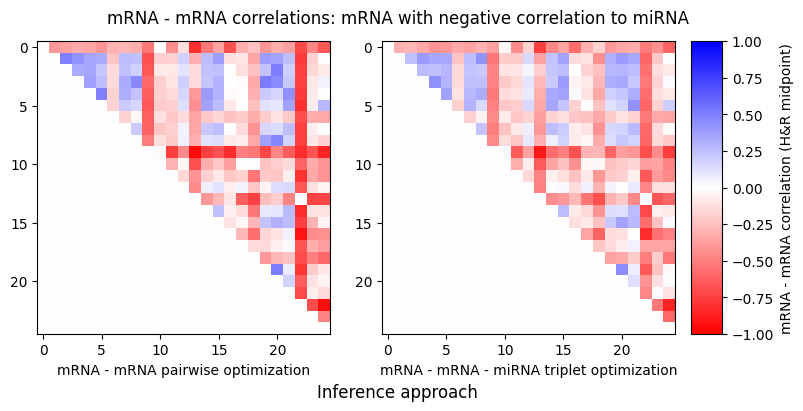

In [33]:
cmap = LinearSegmentedColormap.from_list('a', ['red', 'white', 'blue'])
fig, axs = plt.subplots(1, 3, figsize=(8, 4), gridspec_kw={'width_ratios': [1, 1, 0.1]}, constrained_layout=True)
im = axs[0].imshow(corr_matrix_neg_compare, cmap=cmap, vmin=-1, vmax=1)
im = axs[1].imshow(corr_matrix_neg_triplet, cmap=cmap, vmin=-1, vmax=1)
axs[0].set_xlabel("mRNA - mRNA pairwise optimization")
axs[1].set_xlabel("mRNA - mRNA - miRNA triplet optimization")
fig.supxlabel("Inference approach")
fig.suptitle("mRNA - mRNA correlations: mRNA with negative correlation to miRNA")
plt.colorbar(im, cax=axs[2], label="mRNA - mRNA correlation (H&R midpoint)")
plt.show()

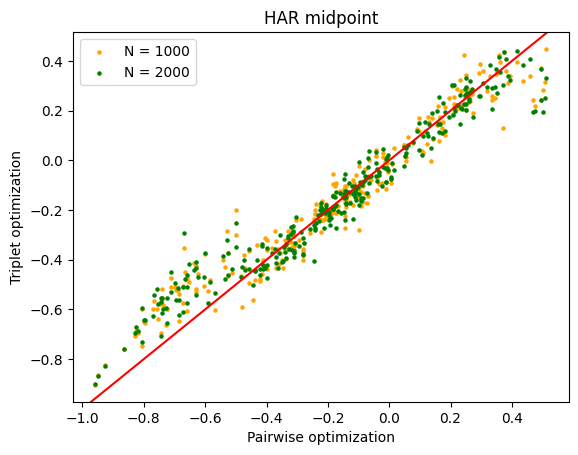

In [53]:
# midpoints consistent
plt.scatter(HAR_mid_neg, HAR_mid_neg_triplet_12, s=5, color="orange", label="N = 1000")
plt.scatter(HAR_mid_neg, HAR_mid_neg_triplet_12_N, s=5, color="green", label="N = 2000")
plt.xlabel("Pairwise optimization")
plt.ylabel("Triplet optimization")
plt.title("HAR midpoint")
plt.axline([0]*2, [0.1]*2, color="red")
plt.legend()
plt.show()

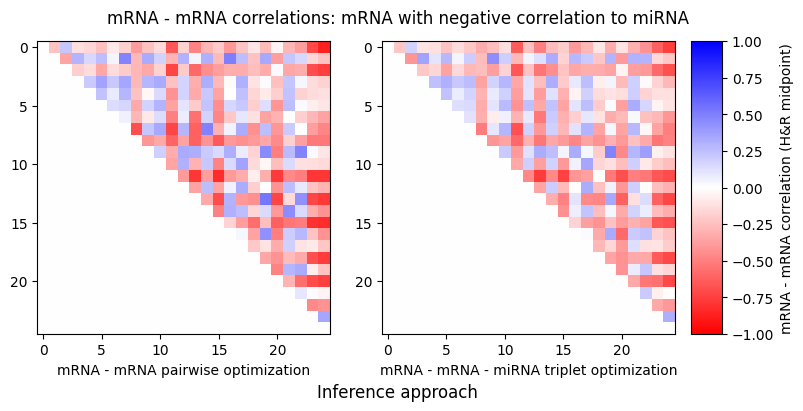

In [ ]:
# MIR3655

## Tighter Intervals

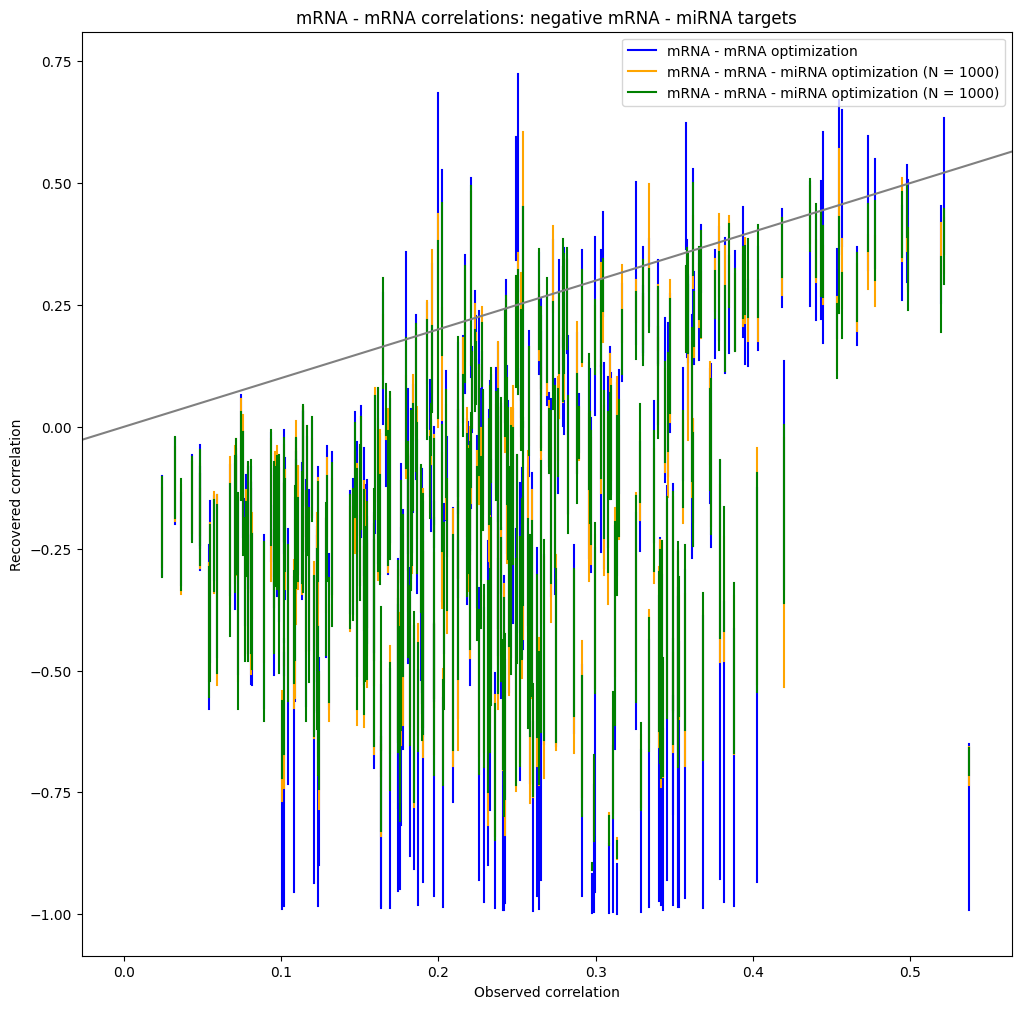

In [46]:
fig, axs = plt.subplots(figsize=(12, 12))
axs.plot(
    [OB_neg[:, 0], OB_neg[:, 0]],
    [HAR_intervals_neg[:, 0], HAR_intervals_neg[:, 1]],
    color="blue"
);
axs.plot(
    [OB_neg[:, 0], OB_neg[:, 0]],
    [HAR_intervals_neg_triplet_12[:, 0], HAR_intervals_neg_triplet_12[:, 1]],
    color="orange"
);
axs.plot(
    [OB_neg[:, 0], OB_neg[:, 0]],
    [HAR_intervals_neg_triplet_12_N[:, 0], HAR_intervals_neg_triplet_12_N[:, 1]],
    color="green"
);
axs.plot([], [], color="blue", label="mRNA - mRNA optimization")
axs.plot([], [], color="orange", label="mRNA - mRNA - miRNA optimization (N = 1000)")
axs.plot([], [], color="green", label="mRNA - mRNA - miRNA optimization (N = 1000)")
axs.axline([0]*2, [0.1]*2, color="grey")
axs.set_title("mRNA - mRNA correlations: negative mRNA - miRNA targets")
axs.set_xlabel("Observed correlation")
axs.set_ylabel("Recovered correlation")
plt.legend()
plt.show()

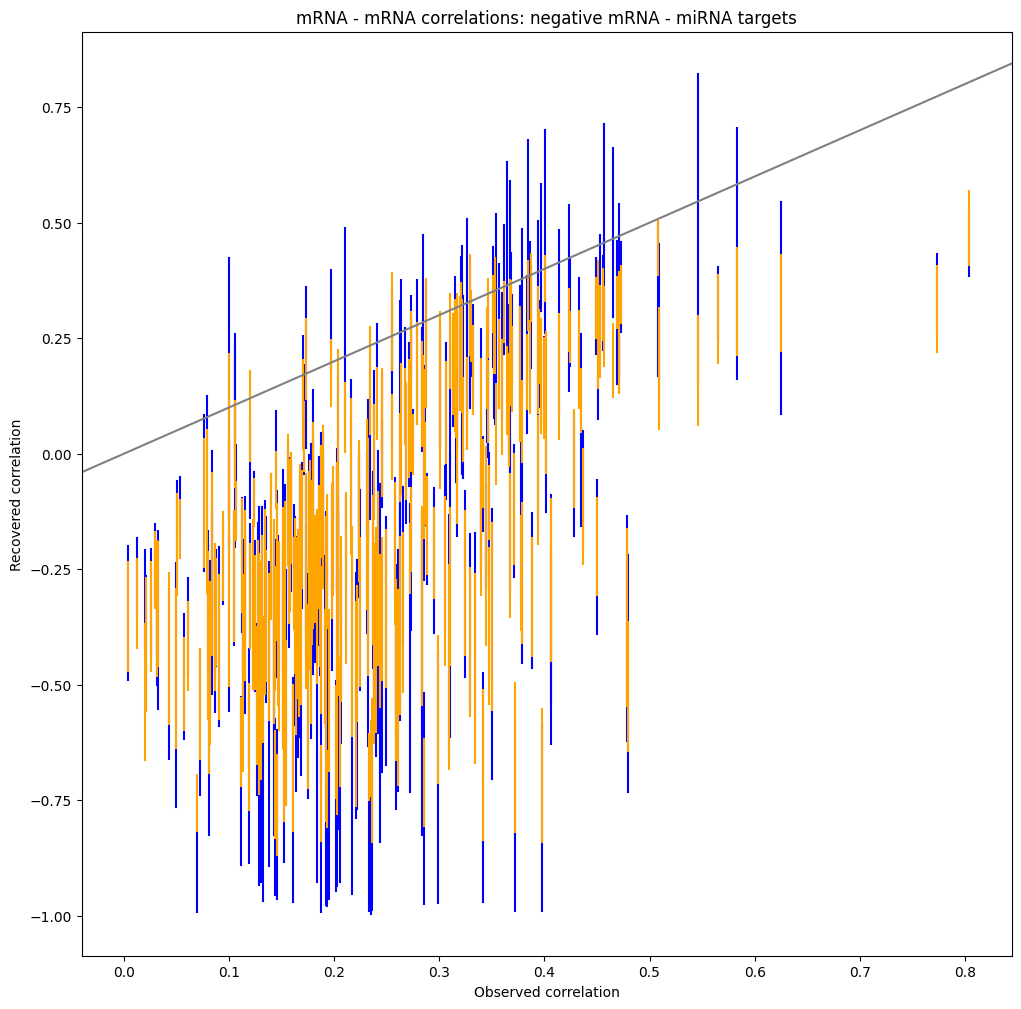

### Higher N

Triplet intervals remain tighter than pairwise when N increased from 1000 to 2000.

Evidence that tighter intervals are not just because HAR explores the higher dimensional space less when optimizing over triplets, but instead a genuine tightening of constraints by including extra information i.e. triplet moments, consistency of paired miRNA - mRNA moments

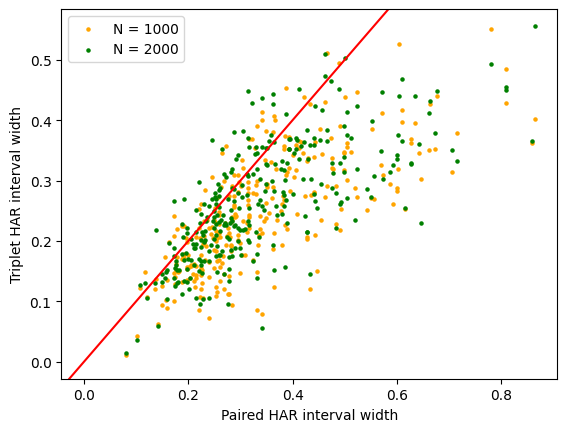

In [49]:
width = HAR_intervals_neg[:, 1] - HAR_intervals_neg[:, 0]
width_triplet = HAR_intervals_neg_triplet_12[:, 1] - HAR_intervals_neg_triplet_12[:, 0]
width_triplet_N = HAR_intervals_neg_triplet_12_N[:, 1] - HAR_intervals_neg_triplet_12_N[:, 0]
plt.scatter(width, width_triplet, s=5, color="orange", label="N = 1000")
plt.scatter(width, width_triplet_N, s=5, color="green", label="N = 2000")
plt.axline([0]*2, [0.1]*2, color="red")
plt.legend()
plt.xlabel("Paired HAR interval width")
plt.ylabel("Triplet HAR interval width")
plt.show()

# Network Correlations

In [302]:
# compute correlations between miRNA + multiple mRNA: network of RNAs
G = 5
S = G + 1
gene_queries = [
    [[0], [x for x in range(G)]]
]


# construct datasets
data_neg_network = SDP_miRNA.dataset.Dataset()
data_neg_network.construct_dataset_adata(
    adata_miRNA[:, adata_miRNA.var['GeneName'] == miRNA],
    adata_neg,
    beta,
    gene_queries
)

# bootstrap
data_neg_network.bootstrap(d=3)

100%|██████████| 1/1 [00:00<00:00,  2.49it/s]


In [303]:
data_neg_network.moment_bounds.shape

(2, 1, 84)

In [317]:
# model free interacting H&R
MF_int_neg_network = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data_neg_network, d=3, N=5000)
MF_int_neg_network.analyse_dataset()

100%|██████████| 1/1 [00:45<00:00, 45.38s/it]


In [318]:
# H&R correlations
Sigma_interval = np.zeros((2, S, S))
for i in range(S):
    for j in range(i + 1, S):
        _, HAR_intervals_neg_network = MF_int_neg_network.compute_dataset_correlation(Sx=i, Sy=j)
        Sigma_interval[:, i, j] = HAR_intervals_neg_network.squeeze()

100%|██████████| 1/1 [00:00<00:00,  1.16it/s]


In [319]:
# H&R midpoints
Sigma_mid = (Sigma_interval[0, :, :] + Sigma_interval[1, :, :]) / 2

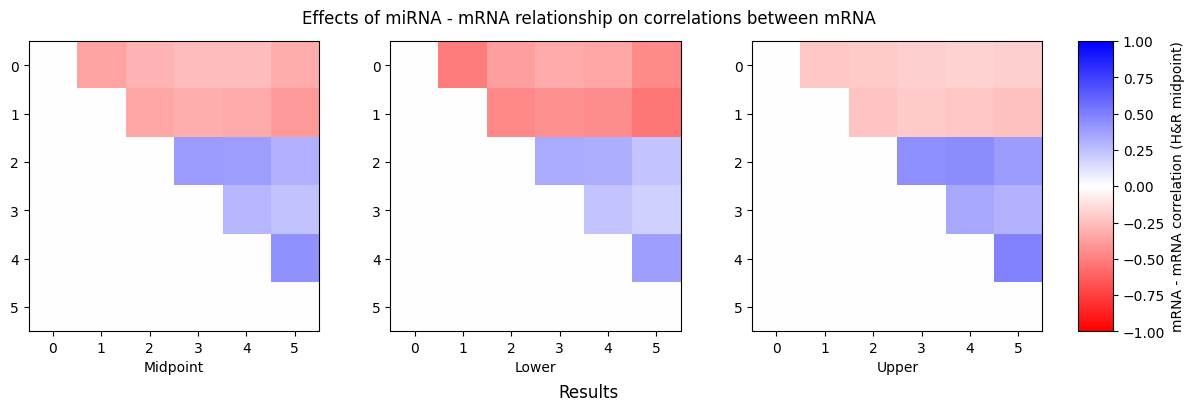

In [320]:
cmap = LinearSegmentedColormap.from_list('a', ['red', 'white', 'blue'])
fig, axs = plt.subplots(1, 4, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 1, 1, 0.1]}, constrained_layout=True)
im = axs[0].imshow(Sigma_mid, cmap=cmap, vmin=-1, vmax=1)
im = axs[1].imshow(Sigma_interval[0, :, :], cmap=cmap, vmin=-1, vmax=1)
im = axs[2].imshow(Sigma_interval[1, :, :], cmap=cmap, vmin=-1, vmax=1)
axs[0].set_xlabel("Midpoint")
axs[1].set_xlabel("Lower")
axs[2].set_xlabel("Upper")
fig.supxlabel("Results")
fig.suptitle("Effects of miRNA - mRNA relationship on correlations between mRNA")
plt.colorbar(im, cax=axs[3], label="mRNA - mRNA correlation (H&R midpoint)")
plt.show()

# Model Explanations

In [54]:
import SDP_miRNA.simulation

### (1) mu = 0.1, chi = 0.2

In [100]:
# settings
alphar = 20
deltar = 1
alphas = 20
deltas = 1
k = 0.05
mu = 0.1
chi = 0.2
pdeg = 0.8

# rates
alpha1 = alpha2 = alphar
delta1 = delta2 = deltar
alpahs = alphas
deltas = deltas
k1 = k2 = k
l1 = l2 = (1 - pdeg) * mu
beta1 = beta2 = pdeg * (1 - chi) * mu
eta1 = eta2 = pdeg * chi * mu

stoch_inp = np.array([
    [0, 0, 0, 0, 0], # r1 tx
    [1, 0, 0, 0, 0], # r1 deg
    [0, 0, 0, 0, 0], # r2 tx
    [0, 1, 0, 0, 0], # r2 deg
    [0, 0, 0, 0, 0], # s tx
    [0, 0, 1, 0, 0], # s deg
    [1, 0, 1, 0, 0], # c1 tx
    [0, 1, 1, 0, 0], # c2 tx
    [0, 0, 0, 1, 0], # c1 dis
    [0, 0, 0, 0, 1], # c2 dis
    [0, 0, 0, 1, 0], # c1 rec
    [0, 0, 0, 0, 1], # c2 rec
    [0, 0, 0, 1, 0], # c1 deg
    [0, 0, 0, 0, 1], # c2 deg
])

stoch_out = np.array([
    [1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1],
    [1, 0, 1, 0, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
])

rates = np.array([
    alpha1,
    delta1,
    alpha2,
    delta2,
    alphas,
    deltas,
    k1,
    k2,
    l1,
    l2,
    beta1,
    beta2,
    eta1,
    eta2
])

initial = None
tmax = 1100

path, path_times = SDP_miRNA.simulation.gillespie(stoch_inp, stoch_out, rates, initial, tmax)

In [101]:
sample = SDP_miRNA.simulation.uniform_time_samples(path, path_times, tmin=100, tmax=1100, tint=10, n=100)

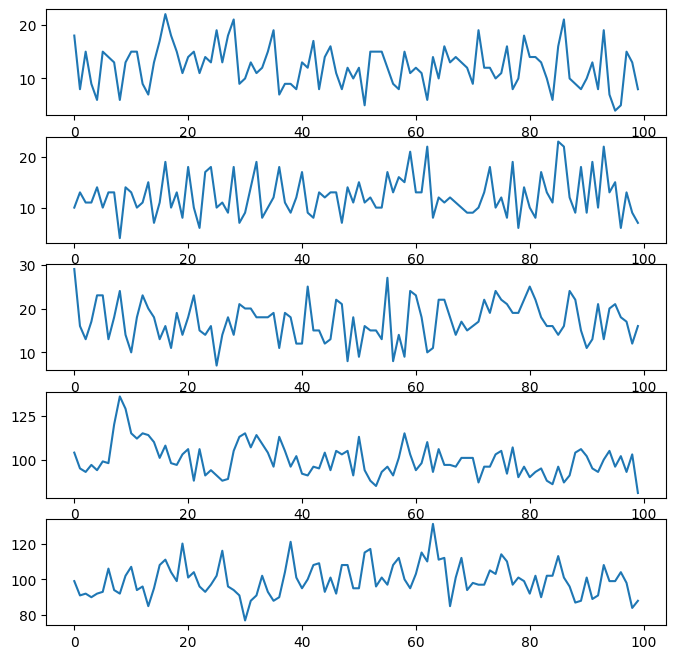

In [102]:
fig, axs = plt.subplots(5, figsize=(8, 8))
for s in range(5):
    axs[s].plot(sample[:, s])

In [ ]:
# corr(r1, r2, s, c1, c2)
Sigma = np.corrcoef(sample.T)
Sigma

array([[ 1.        ,  0.13809599, -0.15142153, -0.19089526,  0.09062765],
       [ 0.13809599,  1.        , -0.18953437,  0.0416984 , -0.02559022],
       [-0.15142153, -0.18953437,  1.        ,  0.01144341, -0.20631113],
       [-0.19089526,  0.0416984 ,  0.01144341,  1.        , -0.18095031],
       [ 0.09062765, -0.02559022, -0.20631113, -0.18095031,  1.        ]])

In [ ]:
# corr(r1 + c1, r2 + c2)
T1 = sample[:, 0] + sample[:, 3]
T2 = sample[:, 1] + sample[:, 4]
np.corrcoef(np.vstack([T1, T2]))

array([[ 1.       , -0.0921298],
       [-0.0921298,  1.       ]])

In [ ]:
# corr(s + c1, r1 + c1, r2 + c2)
ST = sample[:, 2] + sample[:, 3] + sample[:, 4]
T1 = sample[:, 0] + sample[:, 3]
T2 = sample[:, 1] + sample[:, 4]
np.corrcoef(np.vstack([ST, T1, T2]))

array([[ 1.        ,  0.58432807,  0.47785377],
       [ 0.58432807,  1.        , -0.0921298 ],
       [ 0.47785377, -0.0921298 ,  1.        ]])

#### Example

NOTE: results variable, sometimes just get low / positive correlation

In [88]:
Sigma = np.corrcoef(sample.T)
Sigma

array([[ 1.        ,  0.06499194, -0.20440516, -0.13298156,  0.05455515],
       [ 0.06499194,  1.        , -0.39633381, -0.21821085,  0.0615935 ],
       [-0.20440516, -0.39633381,  1.        ,  0.04677462,  0.02071696],
       [-0.13298156, -0.21821085,  0.04677462,  1.        , -0.25720047],
       [ 0.05455515,  0.0615935 ,  0.02071696, -0.25720047,  1.        ]])

- targets negative correlated to miRNA (r1, s), (r2, s)
- targets positively correlated with each other (r1, r2)
- complexes negatively correlated with each other (c1, c2)

In [89]:
T1 = sample[:, 0] + sample[:, 3]
T2 = sample[:, 1] + sample[:, 4]
np.corrcoef(np.vstack([T1, T2]))

array([[ 1.        , -0.27400604],
       [-0.27400604,  1.        ]])

- total target RNA negtively correlated (r1 + c1, r2 + c2)

### (2) mu = 0.01, chi = 0.2

In [101]:
# settings
alphar = 20
deltar = 1
alphas = 20
deltas = 1
k = 0.05
mu = 0.01
chi = 0.2
pdeg = 0.8

# rates
alpha1 = alpha2 = alphar
delta1 = delta2 = deltar
alpahs = alphas
deltas = deltas
k1 = k2 = k
l1 = l2 = (1 - pdeg) * mu
beta1 = beta2 = pdeg * (1 - chi) * mu
eta1 = eta2 = pdeg * chi * mu

stoch_inp = np.array([
    [0, 0, 0, 0, 0], # r1 tx
    [1, 0, 0, 0, 0], # r1 deg
    [0, 0, 0, 0, 0], # r2 tx
    [0, 1, 0, 0, 0], # r2 deg
    [0, 0, 0, 0, 0], # s tx
    [0, 0, 1, 0, 0], # s deg
    [1, 0, 1, 0, 0], # c1 tx
    [0, 1, 1, 0, 0], # c2 tx
    [0, 0, 0, 1, 0], # c1 dis
    [0, 0, 0, 0, 1], # c2 dis
    [0, 0, 0, 1, 0], # c1 rec
    [0, 0, 0, 0, 1], # c2 rec
    [0, 0, 0, 1, 0], # c1 deg
    [0, 0, 0, 0, 1], # c2 deg
])

stoch_out = np.array([
    [1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1],
    [1, 0, 1, 0, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
])

rates = np.array([
    alpha1,
    delta1,
    alpha2,
    delta2,
    alphas,
    deltas,
    k1,
    k2,
    l1,
    l2,
    beta1,
    beta2,
    eta1,
    eta2
])

initial = np.array([20, 20, 20, 1000, 1000])
tmax = 1100

path, path_times = SDP_miRNA.simulation.gillespie(stoch_inp, stoch_out, rates, initial, tmax)

In [102]:
sample = SDP_miRNA.simulation.uniform_time_samples(path, path_times, tmin=100, tmax=1100, tint=10, n=100)

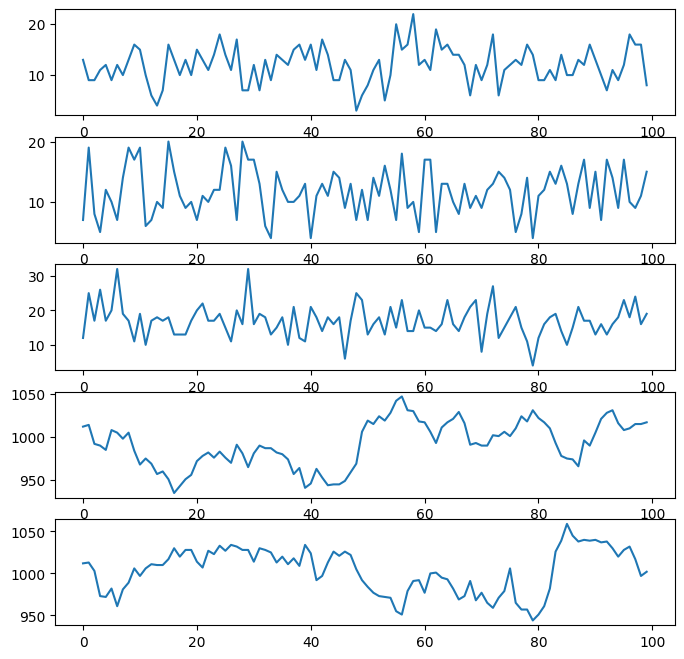

In [103]:
fig, axs = plt.subplots(5, figsize=(8, 8))
for s in range(5):
    axs[s].plot(sample[:, s])

In [104]:
Sigma = np.corrcoef(sample.T)
Sigma

array([[ 1.        , -0.0702009 , -0.06841297,  0.10071742, -0.0574164 ],
       [-0.0702009 ,  1.        ,  0.03556757, -0.03955996,  0.13535765],
       [-0.06841297,  0.03556757,  1.        ,  0.04834007, -0.0714215 ],
       [ 0.10071742, -0.03955996,  0.04834007,  1.        , -0.55069738],
       [-0.0574164 ,  0.13535765, -0.0714215 , -0.55069738,  1.        ]])

In [105]:
T1 = sample[:, 0] + sample[:, 3]
T2 = sample[:, 1] + sample[:, 4]
np.corrcoef(np.vstack([T1, T2]))

array([[ 1.        , -0.53688204],
       [-0.53688204,  1.        ]])

- produces a stronger version of the result in (1)

- However, may be slightly unrealistic to go to this extreme, as the complex and so total target RNA increases to very large quantities, even if assuming this is downsampled to ~20%

### (3): mu = 0.1, chi = 0.8

In [106]:
# settings
alphar = 20
deltar = 1
alphas = 20
deltas = 1
k = 0.05
mu = 0.1
chi = 0.8
pdeg = 0.8

# rates
alpha1 = alpha2 = alphar
delta1 = delta2 = deltar
alpahs = alphas
deltas = deltas
k1 = k2 = k
l1 = l2 = (1 - pdeg) * mu
beta1 = beta2 = pdeg * (1 - chi) * mu
eta1 = eta2 = pdeg * chi * mu

stoch_inp = np.array([
    [0, 0, 0, 0, 0], # r1 tx
    [1, 0, 0, 0, 0], # r1 deg
    [0, 0, 0, 0, 0], # r2 tx
    [0, 1, 0, 0, 0], # r2 deg
    [0, 0, 0, 0, 0], # s tx
    [0, 0, 1, 0, 0], # s deg
    [1, 0, 1, 0, 0], # c1 tx
    [0, 1, 1, 0, 0], # c2 tx
    [0, 0, 0, 1, 0], # c1 dis
    [0, 0, 0, 0, 1], # c2 dis
    [0, 0, 0, 1, 0], # c1 rec
    [0, 0, 0, 0, 1], # c2 rec
    [0, 0, 0, 1, 0], # c1 deg
    [0, 0, 0, 0, 1], # c2 deg
])

stoch_out = np.array([
    [1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1],
    [1, 0, 1, 0, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
])

rates = np.array([
    alpha1,
    delta1,
    alpha2,
    delta2,
    alphas,
    deltas,
    k1,
    k2,
    l1,
    l2,
    beta1,
    beta2,
    eta1,
    eta2
])

initial = None
tmax = 1100

path, path_times = SDP_miRNA.simulation.gillespie(stoch_inp, stoch_out, rates, initial, tmax)

In [107]:
sample = SDP_miRNA.simulation.uniform_time_samples(path, path_times, tmin=100, tmax=1100, tint=10, n=100)

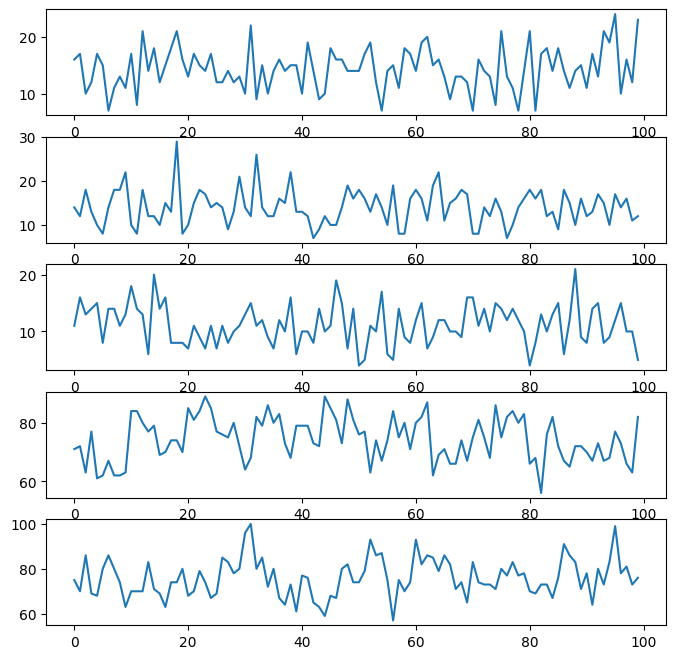

In [108]:
fig, axs = plt.subplots(5, figsize=(8, 8))
for s in range(5):
    axs[s].plot(sample[:, s])

In [109]:
Sigma = np.corrcoef(sample.T)
Sigma

array([[ 1.        ,  0.03178575, -0.15350776,  0.04456237,  0.0438898 ],
       [ 0.03178575,  1.        , -0.1329359 , -0.13977421,  0.06493441],
       [-0.15350776, -0.1329359 ,  1.        , -0.11394391,  0.03123261],
       [ 0.04456237, -0.13977421, -0.11394391,  1.        , -0.20532524],
       [ 0.0438898 ,  0.06493441,  0.03123261, -0.20532524,  1.        ]])

In [110]:
T1 = sample[:, 0] + sample[:, 3]
T2 = sample[:, 1] + sample[:, 4]
np.corrcoef(np.vstack([T1, T2]))

array([[ 1.        , -0.18769114],
       [-0.18769114,  1.        ]])

- also works with more co-degradation of complexes

## Stronger Coupling

### (4): mu = 0.1, chi = 0.2

In [111]:
# settings
alphar = 30
deltar = 1
alphas = 12
deltas = 1
k = 0.15
mu = 0.1
chi = 0.2
pdeg = 0.8

# rates
alpha1 = alpha2 = alphar
delta1 = delta2 = deltar
alpahs = alphas
deltas = deltas
k1 = k2 = k
l1 = l2 = (1 - pdeg) * mu
beta1 = beta2 = pdeg * (1 - chi) * mu
eta1 = eta2 = pdeg * chi * mu

stoch_inp = np.array([
    [0, 0, 0, 0, 0], # r1 tx
    [1, 0, 0, 0, 0], # r1 deg
    [0, 0, 0, 0, 0], # r2 tx
    [0, 1, 0, 0, 0], # r2 deg
    [0, 0, 0, 0, 0], # s tx
    [0, 0, 1, 0, 0], # s deg
    [1, 0, 1, 0, 0], # c1 tx
    [0, 1, 1, 0, 0], # c2 tx
    [0, 0, 0, 1, 0], # c1 dis
    [0, 0, 0, 0, 1], # c2 dis
    [0, 0, 0, 1, 0], # c1 rec
    [0, 0, 0, 0, 1], # c2 rec
    [0, 0, 0, 1, 0], # c1 deg
    [0, 0, 0, 0, 1], # c2 deg
])

stoch_out = np.array([
    [1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1],
    [1, 0, 1, 0, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
])

rates = np.array([
    alpha1,
    delta1,
    alpha2,
    delta2,
    alphas,
    deltas,
    k1,
    k2,
    l1,
    l2,
    beta1,
    beta2,
    eta1,
    eta2
])

initial = None
tmax = 1100

path, path_times = SDP_miRNA.simulation.gillespie(stoch_inp, stoch_out, rates, initial, tmax)

In [112]:
sample = SDP_miRNA.simulation.uniform_time_samples(path, path_times, tmin=100, tmax=1100, tint=10, n=100)

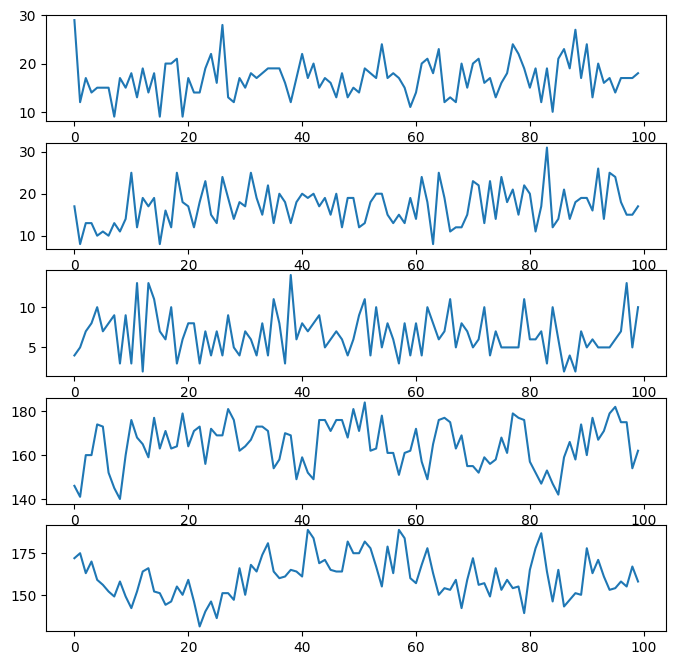

In [113]:
fig, axs = plt.subplots(5, figsize=(8, 8))
for s in range(5):
    axs[s].plot(sample[:, s])

In [114]:
Sigma = np.corrcoef(sample.T)
Sigma

array([[ 1.        ,  0.37897467, -0.31501396, -0.07734261,  0.02059953],
       [ 0.37897467,  1.        , -0.38811238,  0.14280441, -0.02016534],
       [-0.31501396, -0.38811238,  1.        ,  0.08864311, -0.01281704],
       [-0.07734261,  0.14280441,  0.08864311,  1.        , -0.28497532],
       [ 0.02059953, -0.02016534, -0.01281704, -0.28497532,  1.        ]])

In [115]:
T1 = sample[:, 0] + sample[:, 3]
T2 = sample[:, 1] + sample[:, 4]
np.corrcoef(np.vstack([T1, T2]))

array([[ 1.        , -0.15618362],
       [-0.15618362,  1.        ]])

## More Targets

In [171]:
# settings
alphar = 20
deltar = 1
alphas = 20
deltas = 1
k = 0.15

mu = 0.1
chi = 0.2
pdeg = 0.8

ell = (1 - pdeg) * mu
beta = pdeg * (1 - chi) * mu
eta = pdeg * chi * mu

targets = 10

R = 2 + targets * 6
S = 1 + 2 * targets

stoch_inp = np.zeros((R, S))
stoch_out = np.zeros((R, S))
rates = np.zeros(R)

# s tx, deg
stoch_out[0, 0] = 1
rates[0] = alphas
stoch_inp[1, 0] = 1
rates[1] = deltas

for i in range(targets):

    r = 2 + 6 * i

    ri = 1 + 2 * i
    ci = 1 + 2 * i + 1

    # ri tx
    stoch_out[r, ri] = 1
    rates[r] = alphar

    # ri deg
    stoch_inp[r + 1, ri] = 1
    rates[r + 1] = deltar

    # ci tx
    stoch_inp[r + 2, 0] = 1
    stoch_inp[r + 2, ri] = 1
    stoch_out[r + 2, ci] = 1
    rates[r + 2] = k

    # ci dis
    stoch_inp[r + 3, ci] = 1
    stoch_out[r + 3, 0] = 1
    stoch_out[r + 3, ri] = 1
    rates[r + 3] = ell

    # ci rec
    stoch_inp[r + 4, ci] = 1
    stoch_out[r + 4, 0] = 1
    rates[r + 4] = beta

    # ci deg
    stoch_inp[r + 5, ci] = 1
    rates[r + 5] = eta

# convert to int
stoch_inp = stoch_inp.astype(int)
stoch_out = stoch_out.astype(int)

In [172]:
initial = None
tmax = 1100

path, path_times = SDP_miRNA.simulation.gillespie(stoch_inp, stoch_out, rates, initial, tmax)

In [173]:
sample = SDP_miRNA.simulation.uniform_time_samples(path, path_times, tmin=100, tmax=1100, tint=10, n=100)

In [178]:
#fig, axs = plt.subplots(S, figsize=(8, 8))
#for s in range(S):
#    axs[s].plot(sample[:, s])

### 10 targets

Very interesting results
- corr(s, ri) some are weak but some are strongly negative, even for symmetric parameters
    - shows strong interactions possible when multiple targets
    - shows competition between targets
        - suggests explanation for many mRNA being possible targets, but only some actually regulated
- corr(ri, rj) mostly weak, some negative but more positive
- corr(ri + ci, rj + cj) mix of negative and positive

In [179]:
np.mean(sample, axis=0)

array([ 5.22, 12.  , 93.43, 11.86, 93.06, 12.73, 94.99, 12.45, 95.14,
       12.43, 94.28, 11.85, 95.06, 12.57, 98.43, 12.33, 94.66, 12.41,
       95.94, 12.51, 94.33])

In [204]:
# corr(s, ri)
Sigma = np.corrcoef(sample.T)
corr_targets = Sigma[0, np.array(range(1, S, 2))]
corr_targets

array([-0.04887508,  0.06629248, -0.34230475, -0.28429067,  0.03455058,
       -0.1203516 , -0.00449767, -0.07562275, -0.18205899, -0.16239943])

In [205]:
# corr(ri, rj)
corr_between_targets = np.corrcoef(np.vstack([sample[:, s] for s in range(1, S, 2)]))[np.triu_indices(targets, k=1)]
corr_between_targets

array([ 0.10709262,  0.036607  ,  0.04795913, -0.07731796,  0.08596035,
       -0.06319974,  0.11558346, -0.00638789,  0.15744564,  0.19289716,
        0.17220566,  0.13020676,  0.0071091 ,  0.0449731 , -0.03266798,
        0.05008312,  0.04379371,  0.15252604,  0.04205367, -0.09885153,
        0.19467074,  0.01986839,  0.23342319,  0.11695858, -0.05986292,
        0.11515877,  0.06892959,  0.03908822, -0.00737814, -0.03241238,
        0.16727513,  0.05506179, -0.08353395, -0.01916149, -0.08537795,
        0.10827949,  0.11649548,  0.09481688,  0.13473846, -0.05676101,
        0.17755198, -0.01157379,  0.12560989, -0.0805342 ,  0.17517421])

In [206]:
# corr(ri + ci, rj + cj)
corr_between_total_targets = np.corrcoef(np.vstack([sample[:, s] + sample[:, s + 1] for s in range(1, S, 2)]))[np.triu_indices(targets, k=1)]
corr_between_total_targets

array([ 9.81974406e-02, -3.01576675e-02, -3.47380314e-01, -1.19066518e-01,
        1.93144498e-01,  5.32869942e-02,  1.53845726e-01,  1.21469705e-02,
        1.73580760e-01,  1.65160184e-02, -1.67121032e-01, -1.02210905e-01,
        4.91543555e-02,  9.07564010e-02, -2.13504051e-01,  8.15635706e-02,
       -9.40500903e-02, -1.49700666e-01,  6.85566593e-02, -2.78920448e-02,
        1.15685780e-01,  6.13685551e-02, -2.76064233e-02,  1.30126023e-01,
       -5.02161614e-02, -1.89567959e-01, -1.06871811e-01,  3.40241273e-04,
        5.59644123e-02,  3.57089916e-02, -6.83337580e-02,  9.83733826e-02,
        2.07178461e-01,  2.09441518e-01, -7.04755935e-02,  1.00530348e-01,
       -8.19288626e-02, -9.02940890e-02, -6.28715265e-02,  1.69042502e-01,
       -4.40155788e-02, -5.29136501e-02,  2.59340664e-01,  2.23267903e-01,
        7.18035026e-02])

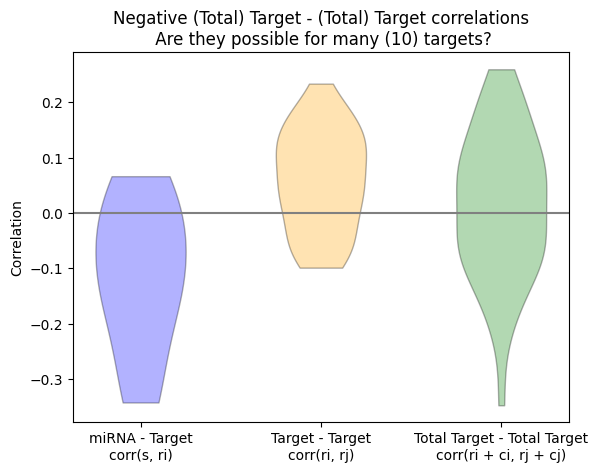

In [210]:
fig, axs = plt.subplots()
vp = axs.violinplot(
    dataset=corr_targets,
    positions=[0],
    showextrema=False,
    side="both"
)
plt.setp(vp['bodies'], facecolor="blue", edgecolor='black')
vp = axs.violinplot(
    dataset=corr_between_targets,
    positions=[1],
    showextrema=False,
    side="both"
)
plt.setp(vp['bodies'], facecolor="orange", edgecolor='black')
vp = axs.violinplot(
    dataset=corr_between_total_targets,
    positions=[2],
    showextrema=False,
    side="both"
)
plt.setp(vp['bodies'], facecolor="green", edgecolor='black')
axs.axhline(0, color="grey")
axs.set_xticks([0, 1, 2])
axs.set_xticklabels(["miRNA - Target\ncorr(s, ri)", "Target - Target\ncorr(ri, rj)", "Total Target - Total Target\ncorr(ri + ci, rj + cj)"])
axs.set_ylabel("Correlation")
axs.set_title("Negative (Total) Target - (Total) Target correlations\n Are they possible for many (10) targets?")
plt.show()

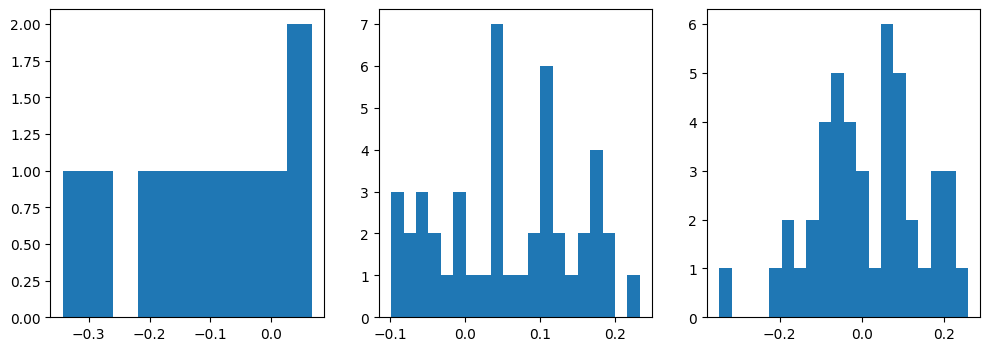

In [221]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].hist(corr_targets, bins=10)
axs[1].hist(corr_between_targets, bins=20)
axs[2].hist(corr_between_total_targets, bins=20)
plt.show()

### 5 targets

In [168]:
# corr(s, ri)
Sigma = np.corrcoef(sample.T)
Sigma[0, np.array(range(1, S, 2))]

array([-0.20564309, -0.17723672, -0.09775322, -0.10512973, -0.24474092])

In [169]:
# corr(ri, rj)
np.corrcoef(np.vstack([sample[:, s] for s in range(1, S, 2)]))[np.triu_indices(targets, k=1)]

array([ 3.77693248e-03,  2.79782739e-01,  1.34506312e-01,  6.13329893e-02,
        6.14234759e-02,  2.52442587e-04,  4.87286919e-02,  1.01269040e-01,
       -1.08740983e-01,  1.43564195e-01])

In [170]:
# corr(ri + ci, rj + cj)
np.corrcoef(np.vstack([sample[:, s] + sample[:, s + 1] for s in range(1, S, 2)]))[np.triu_indices(targets, k=1)]

array([-0.08045274, -0.02819696,  0.04292415, -0.10824105,  0.07800121,
       -0.11483336, -0.16784388, -0.18460065, -0.2198952 , -0.17701394])

### 3 targets

In [ ]:
# corr(s, ri)
Sigma = np.corrcoef(sample.T)
Sigma[0, np.array(range(1, S, 2))]

array([-0.387627  , -0.21584051, -0.38395965])

In [ ]:
# corr(ri, rj)
np.corrcoef(np.vstack([sample[:, s] for s in range(1, S, 2)]))[np.triu_indices(targets, k=1)]

array([0.25158163, 0.31506658, 0.17686886])

In [ ]:
# corr(ri + ci, rj + cj)
np.corrcoef(np.vstack([sample[:, s] + sample[:, s + 1] for s in range(1, S, 2)]))[np.triu_indices(targets, k=1)]

array([-0.23560827, -0.28388964, -0.33602041])

# Appendix

## Estimate comparison: AL vs HAR midpoints

Broadly similar, especially for positive and independent mRNA (orange, green), some differences for negative mRNA (blue) where AL produces more extreme values

For mRNA - mRNA pairs with strong negative observed correlation AL breaks down and produces values below -1

Overall suggests HAR midpoint is a good single value to use

Text(0.5, 1.0, 'Correlation estimate comparison')

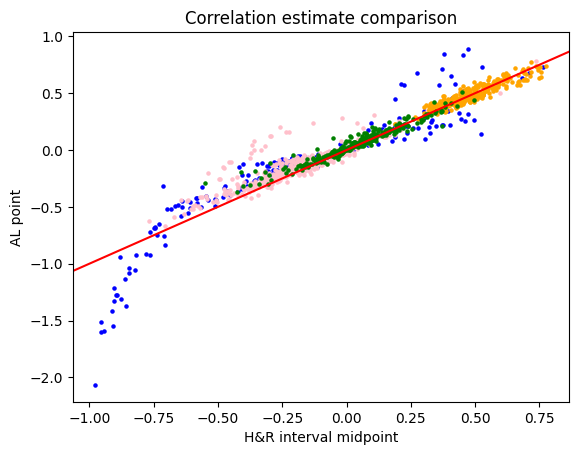

In [176]:
plt.scatter(HAR_mid_neg, AL_neg[:, 0], s=5, color="blue")
plt.scatter(HAR_mid_neg_pos, AL_neg_pos[:, 0], s=5, color="pink")
plt.scatter(HAR_mid_pos, AL_pos[:, 0], s=5, color="orange")
plt.scatter(HAR_mid_ind, AL_ind[:, 0], s=5, color="green")
plt.axline([0]*2, [0.1]*2, color="red")
plt.xlabel("H&R interval midpoint")
plt.ylabel("AL point")
plt.title("Correlation estimate comparison")

Text(0.5, 1.0, 'Correlation estimate comparison')

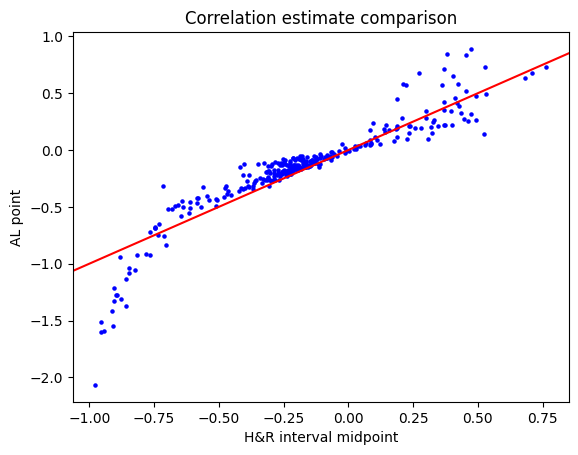

In [147]:
plt.scatter(HAR_mid_neg, AL_neg[:, 0], s=5, color="blue")
#plt.scatter(HAR_mid_pos, AL_pos[:, 0], s=5, color="orange")
#plt.scatter(HAR_mid_ind, AL_ind[:, 0], s=5, color="green")
plt.axline([0]*2, [0.1]*2, color="red")
plt.xlabel("H&R interval midpoint")
plt.ylabel("AL point")
plt.title("Correlation estimate comparison")

## Selection code

In [ ]:
'''
simple way to subset using indices
but may lead to errors if size of result & adata not same
'''

# subset adata to interacting pcRNA
#mask_int = (ind_MF_df == "INFEASIBLE").values.squeeze()
#idxs_int = np.arange(len(mask_int))[mask_int]
#adata_int = adata_pcRNA[:, idxs_int]

# subset adata to independent pcRNA
#mask_ind = (ind_MF_df == "OPTIMAL").values.squeeze()
#idxs_ind = np.arange(len(mask_ind))[mask_ind]
#adata_ind = adata_pcRNA[:, idxs_ind]

In [ ]:
'''
can also subset using gene names and .var
should be safer as names always same
'''

# get names of interacting pcRNA
#mask_int = (ind_MF_df == "INFEASIBLE")
#names_int = mask_int.index[mask_int.values.squeeze()].tolist()

# get names of independent pcRNA
#mask_ind = (ind_MF_df == "OPTIMAL")
#names_ind = mask_ind.index[mask_ind.values.squeeze()].tolist()

# subset adata
#adata_int = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_int)]
#adata_ind = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_ind)]